# Exercise on Airbnb Copenhagen (exploratory analysis, kNN)

This exercise deals with Airbnb listings in Copenhagen. The data is collected from [Inside Airbnb](http://insideairbnb.com/copenhagen). Feel free to explore the website further in order to better understand the data. The data (*listings.csv*) has been collected as raw data and needs to be preprocessed.

In [60]:
from PIL._imaging import display
import sklearn as sk
from wordcloud import WordCloud
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import folium

In [47]:
# load the data
data = pd.read_csv('listings.csv')

# filter relevant columns
data_limited = data[["id",
    "name",
    "host_id"  ,
    "host_name" , 
    "neighbourhood_cleansed"  ,
    "latitude"  ,
    "longitude"  ,
    "room_type"  ,
    "price"  ,
    "minimum_nights"  ,
    "number_of_reviews",  
    "last_review"  ,
    "review_scores_rating"  ,
    "review_scores_accuracy" , 
    "review_scores_cleanliness"  ,
    "review_scores_checkin"  ,
    "review_scores_communication"  ,
    "review_scores_location"  ,
    "review_scores_value"  ,
    "reviews_per_month"  ,
    "calculated_host_listings_count"  ,
    "availability_365",]]

## 1. Initial minimal preprocessing

Start with cleaning and getting overview of the data. Remove rows with no reviews and NaN values. Look at the neighbourhood_cleansed column, replace the misspelled neighbourhoods with the correct names ("Nørrebro", "Østerbro", "Vanløse", "Brønshøj-Husum"). Make sure that the columns are of expected datatypes (ex. price should be numeric).

In [48]:
# removing rows with no reviews
data_filtered = data_limited.loc[data_limited['number_of_reviews'] != 0]

# remove nan
data_filtered = data_filtered.dropna()
data_filtered.head()

,id,name,host_id,host_name,neighbourhood_cleansed,latitude,longitude,room_type,price,minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365
0,6983,Copenhagen 'N Livin',16774,Simon,Nrrebro,55.686410,12.547410,Entire home/apt,$898.00,3,...,4.78,4.79,4.78,4.86,4.89,4.73,4.71,1.08,1,0
1,26057,Lovely house - most attractive area,109777,Kari,Indre By,55.693070,12.576490,Entire home/apt,"$2,600.00",4,...,4.91,4.93,4.96,4.93,4.86,4.94,4.81,0.55,1,303
2,26473,City Centre Townhouse Sleeps 1-10 persons,112210,Julia,Indre By,55.676020,12.575400,Entire home/apt,"$3,250.00",3,...,4.53,4.63,4.44,4.78,4.70,4.89,4.59,2.06,3,56
3,29118,Best Location in Cool Istedgade,125230,Nana,Vesterbro-Kongens Enghave,55.670230,12.555040,Entire home/apt,$725.00,7,...,4.92,4.87,4.73,5.00,5.00,4.87,4.80,0.16,1,59
4,31094,"Beautiful, spacious, central, renovated Penthouse",129976,Ebbe,Vesterbro-Kongens Enghave,55.666602,12.555283,Entire home/apt,"$1,954.00",3,...,4.88,4.82,4.88,4.87,4.82,4.80,4.53,0.13,1,0


In [49]:
# get a list of distinct values from neighbourhood_cleansed columns in data_filtered
neighbourhoods = data_filtered["neighbourhood_cleansed"].unique()

# replace e.g. Nrrbro with Nørrebro in neighbourhood_cleansed column
data_filtered["neighbourhood_cleansed"] = data_filtered["neighbourhood_cleansed"].replace("Nrrebro", "Nørrebro")
data_filtered["neighbourhood_cleansed"] = data_filtered["neighbourhood_cleansed"].replace("sterbro", "Østerbro")
data_filtered["neighbourhood_cleansed"] = data_filtered["neighbourhood_cleansed"].replace("Vanlse", "Vanløse")
data_filtered["neighbourhood_cleansed"] = data_filtered["neighbourhood_cleansed"].replace("Brnshj-Husum", "Brønshøj-Husum")
neighbourhoods = data_filtered["neighbourhood_cleansed"].unique()

data_filtered.head()

,id,name,host_id,host_name,neighbourhood_cleansed,latitude,longitude,room_type,price,minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365
0,6983,Copenhagen 'N Livin',16774,Simon,Nørrebro,55.686410,12.547410,Entire home/apt,$898.00,3,...,4.78,4.79,4.78,4.86,4.89,4.73,4.71,1.08,1,0
1,26057,Lovely house - most attractive area,109777,Kari,Indre By,55.693070,12.576490,Entire home/apt,"$2,600.00",4,...,4.91,4.93,4.96,4.93,4.86,4.94,4.81,0.55,1,303
2,26473,City Centre Townhouse Sleeps 1-10 persons,112210,Julia,Indre By,55.676020,12.575400,Entire home/apt,"$3,250.00",3,...,4.53,4.63,4.44,4.78,4.70,4.89,4.59,2.06,3,56
3,29118,Best Location in Cool Istedgade,125230,Nana,Vesterbro-Kongens Enghave,55.670230,12.555040,Entire home/apt,$725.00,7,...,4.92,4.87,4.73,5.00,5.00,4.87,4.80,0.16,1,59
4,31094,"Beautiful, spacious, central, renovated Penthouse",129976,Ebbe,Vesterbro-Kongens Enghave,55.666602,12.555283,Entire home/apt,"$1,954.00",3,...,4.88,4.82,4.88,4.87,4.82,4.80,4.53,0.13,1,0


In [50]:
# check datatypes of columns
print(data_filtered.dtypes)

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_cleansed                str
latitude                          float64
longitude                         float64
room_type                             str
price                                 str
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
review_scores_rating              float64
review_scores_accuracy            float64
review_scores_cleanliness         float64
review_scores_checkin             float64
review_scores_communication       float64
review_scores_location            float64
review_scores_value               float64
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [51]:
# Remove dollar signs and commas in column price and convert to float
data_filtered["price"] = data_filtered["price"].str.replace("$", "").str.replace(",", "").astype(float)
data_filtered.head()

,id,name,host_id,host_name,neighbourhood_cleansed,latitude,longitude,room_type,price,minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365
0,6983,Copenhagen 'N Livin',16774,Simon,Nørrebro,55.686410,12.547410,Entire home/apt,898.0,3,...,4.78,4.79,4.78,4.86,4.89,4.73,4.71,1.08,1,0
1,26057,Lovely house - most attractive area,109777,Kari,Indre By,55.693070,12.576490,Entire home/apt,2600.0,4,...,4.91,4.93,4.96,4.93,4.86,4.94,4.81,0.55,1,303
2,26473,City Centre Townhouse Sleeps 1-10 persons,112210,Julia,Indre By,55.676020,12.575400,Entire home/apt,3250.0,3,...,4.53,4.63,4.44,4.78,4.70,4.89,4.59,2.06,3,56
3,29118,Best Location in Cool Istedgade,125230,Nana,Vesterbro-Kongens Enghave,55.670230,12.555040,Entire home/apt,725.0,7,...,4.92,4.87,4.73,5.00,5.00,4.87,4.80,0.16,1,59
4,31094,"Beautiful, spacious, central, renovated Penthouse",129976,Ebbe,Vesterbro-Kongens Enghave,55.666602,12.555283,Entire home/apt,1954.0,3,...,4.88,4.82,4.88,4.87,4.82,4.80,4.53,0.13,1,0


## 2. Exploratory data analysis

a) Create a word cloud of hosts' names (column host_name). Check the most common names and compare them to [Danmarks Statistik](https://www.dst.dk/da/Statistik/emner/borgere/navne/navne-i-hele-befolkningen).

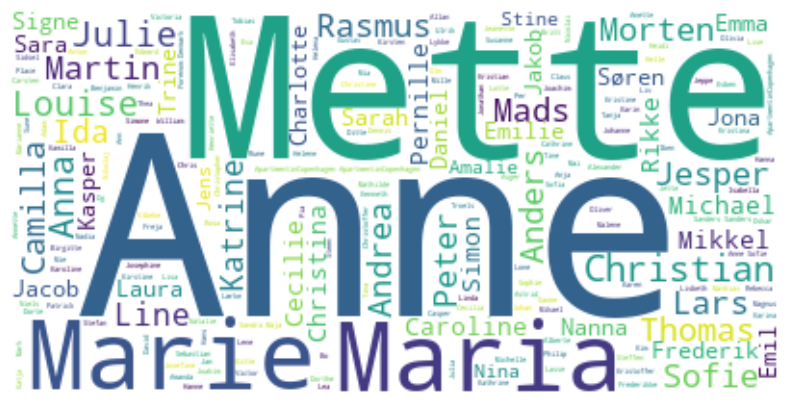

In [52]:
# word cloud of host_name

wordcloud = WordCloud(background_color="white").generate(' '.join(data_filtered["host_name"]))

# Display the generated word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

b) Using non-scaled versions of latitude and longitude, plot the listings data. Compare the distribution to a map of Copenhagen and see if the listings are distributed as expected. Do you see any gaps in the distribution? If so, can you explain why there might be gaps in the distribution?

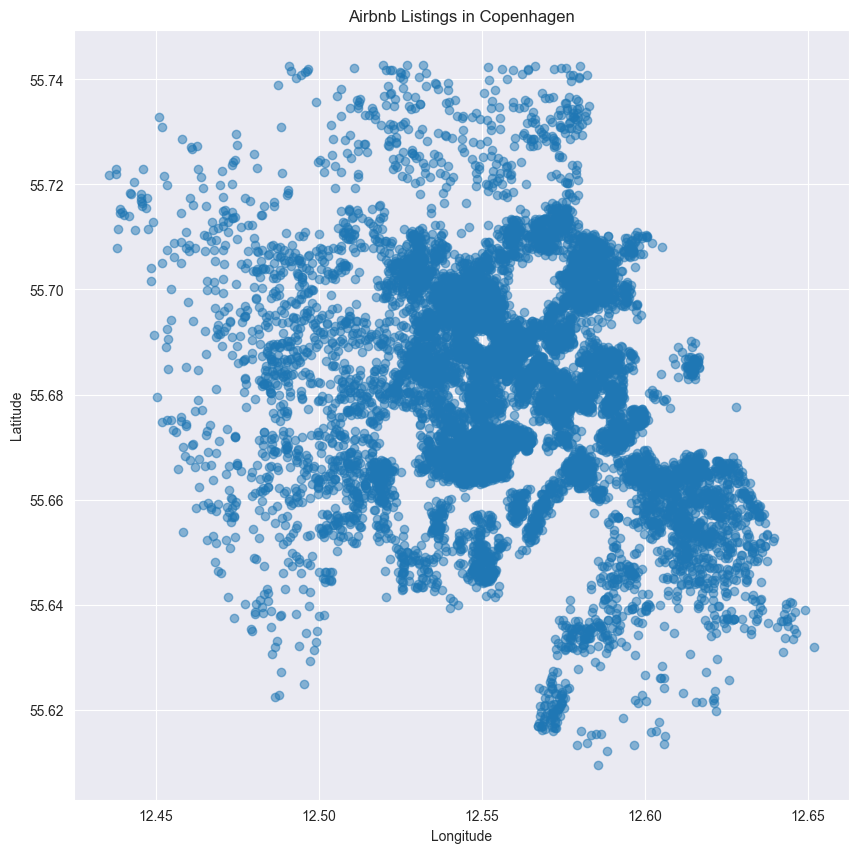

In [53]:
# plot the listings data on a map using latitude and longitude
plt.figure(figsize=(10, 10))
plt.scatter(data_filtered["longitude"], data_filtered["latitude"], alpha=0.5)
plt.title("Airbnb Listings in Copenhagen")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

c) Create a new column with bins of the price column. Use 11 bins, evenly distributed, with the last bin >10,000. Create boxplots of price for each neighborhood. What does this tell you about the listings in Copenhagen? Experiment with other attributes as well (e.g. review scores, minimum nights, etc.) to see how they are distributed between the neighborhoods.

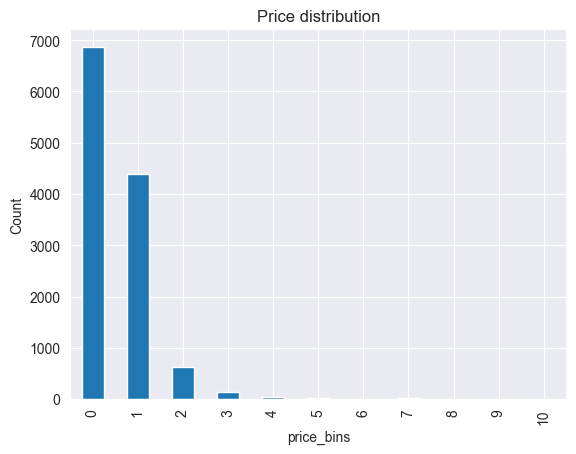

In [54]:
# Define the bin edges
bin_edges = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, float('inf')]

data_bins = data_filtered
# Create a new column 'bins' with the bin edges
data_bins['price_bins'] = pd.cut(data_filtered['price'], bins=bin_edges, labels=False)

# plot the price bins in numbered order
data_bins['price_bins'].value_counts().sort_index().plot(kind='bar')

# Add lables and title
plt.ylabel('Count')
plt.title('Price distribution')

# Display the plot
plt.show()

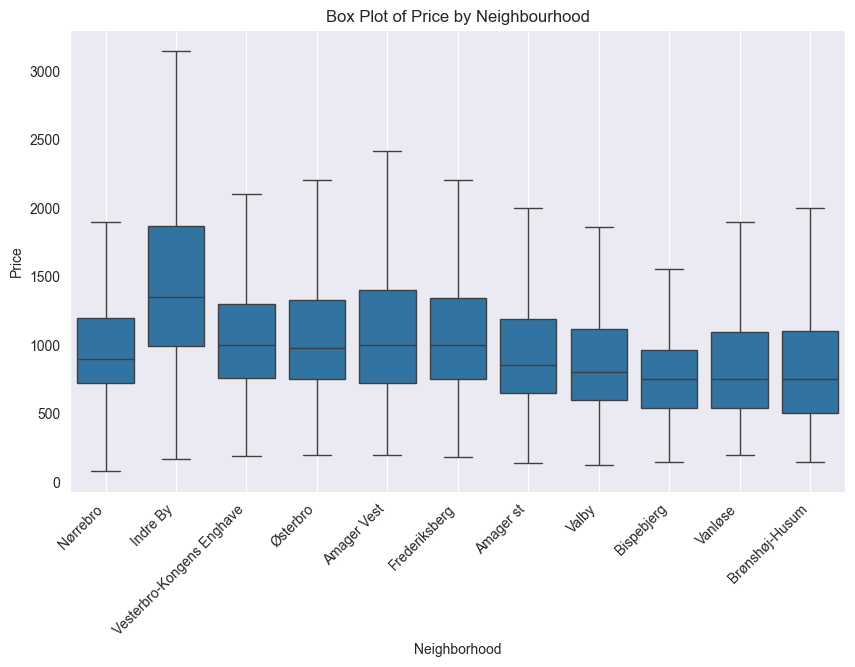

In [55]:
# Create a box plot grouped by 'neighborhood'
plt.figure(figsize=(10, 6))
# showfliers=False will hide the outliers
sns.boxplot(x='neighbourhood_cleansed', y='price', data=data_bins, showfliers=False)

# Add labels and title
plt.xlabel('Neighborhood')
plt.ylabel('Price')
plt.title('Box Plot of Price by Neighbourhood')

# Show the plot
plt.grid()
plt.xticks(rotation=45, ha='right')
plt.show()

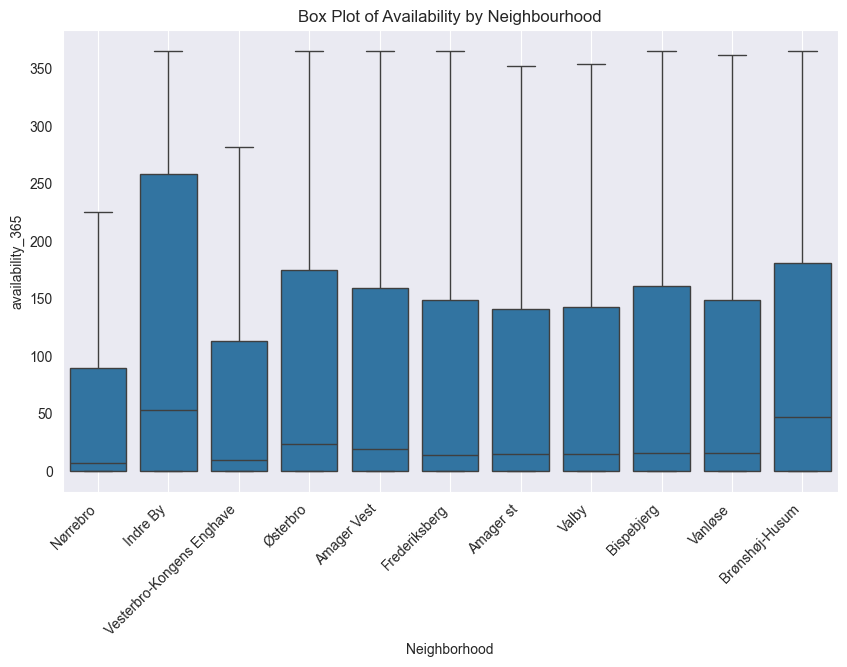

In [56]:
# Create a box plot grouped by 'neighborhood' on availability_365
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood_cleansed', y='availability_365', data=data_bins, showfliers=False)

# Add labels and title
plt.xlabel('Neighborhood')
plt.ylabel('availability_365')
plt.title('Box Plot of Availability by Neighbourhood')

# Show the plot
plt.grid()
plt.xticks(rotation=45, ha='right')
plt.show()

d) Find out which hosts have the most listings and create a bar chart of the top ten hosts with the most listings.

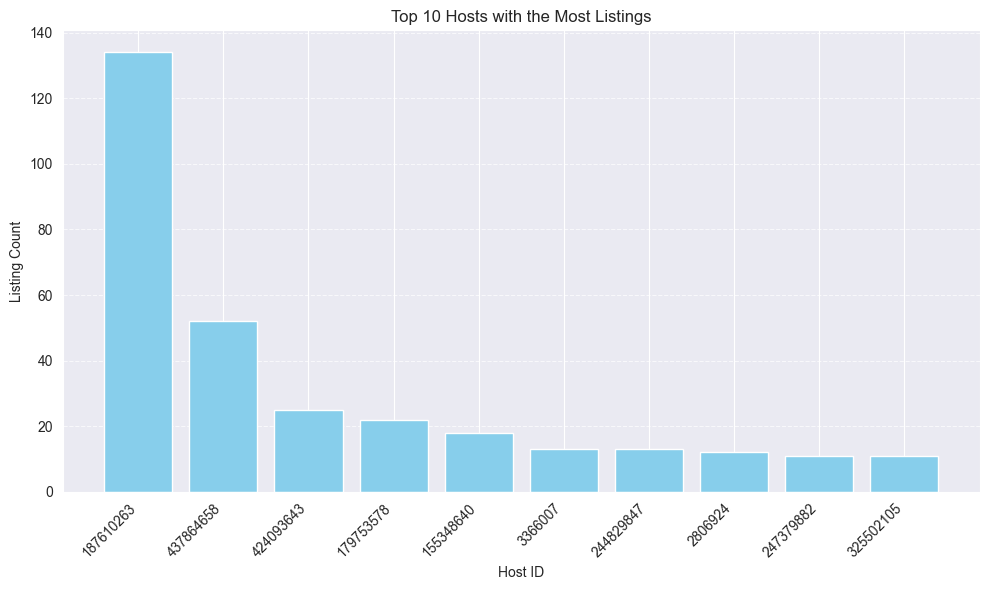

In [57]:
# Calculate the count of listings for each host
host_listing_counts = data_bins['host_id'].value_counts().reset_index()
host_listing_counts.columns = ['host_id', 'listing_count']

# Sort the hosts by listing count and select the top 10
top_hosts = host_listing_counts.nlargest(10, 'listing_count')

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(top_hosts['host_id'].astype(str), top_hosts['listing_count'], color='skyblue')

# Add labels and title
plt.xlabel('Host ID')
plt.ylabel('Listing Count')
plt.title('Top 10 Hosts with the Most Listings')

# Customize the x-axis labels for better readability (optional)
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

e) Do a descriptive analysis of the neighborhoods. Include information about room type in the analysis as well as one other self-chosen feature. The descriptive analysis should contain mean/average, mode, median, standard deviation/variance, minimum, maximum and quartiles.

In [58]:
# group each roomtype by neighbourhood
roomtype = data_bins.groupby(['neighbourhood_cleansed', 'room_type'])['price'].describe()

# calculate mode for each neighbourhood
mode = data_bins.groupby(['neighbourhood_cleansed', 'room_type'])['price'].apply(lambda x: x.mode()[0])

# calculate median for each neighbourhood
median = data_bins.groupby(['neighbourhood_cleansed', 'room_type'])['price'].median()

# group description, mode and median into one dataframe
roomtype = pd.concat([roomtype, mode, median], axis=1)

# rename columns
roomtype.columns = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'mode', 'median']

roomtype # Descriptive statistics for each neighbourhood and room type on price

count         mean          std  \
neighbourhood_cleansed    room_type                                           
Amager Vest               Entire home/apt   909.0  1234.226623   832.696891   
                          Private room      148.0  1032.966216  5299.018095   
                          Shared room         2.0  1051.500000   112.429978   
Amager st                 Entire home/apt   791.0  1093.584071   721.982284   
                          Hotel room          3.0  1296.000000   211.184753   
                          Private room      129.0   549.325581   293.995992   
                          Shared room         1.0  2575.000000          NaN   
Bispebjerg                Entire home/apt   508.0   992.592520  1981.580545   
                          Private room       95.0   488.978947   353.674089   
                          Shared room         1.0   198.000000          NaN   
Brønshøj-Husum            Entire home/apt   216.0  1014.995370   555.669548   
                          Private room       67.0   445.552239   201.631624   
                          Shared room         2.0   211.500000    16.263456   
Frederiksberg             Entire home/apt  1044.0  1292.472222  1958.802772   
                          Private room      133.0   621.706767   567.611220   
Indre By                  Entire home/apt  1702.0  1642.387192  1072.616232   
                          Hotel room         10.0  1077.200000   654.255098   
                          Private room      128.0   698.984375   380.070466   
                          Shared room         4.0   292.000000    67.577116   
Nørrebro                  Entire home/apt  1889.0  1047.742192   583.703218   
                          Private room      165.0   650.121212   760.270040   
                          Shared room         3.0   324.666667   130.481161   
Valby                     Entire home/apt   450.0  1017.968889   635.434691   
                          Private room       89.0   498.157303   288.616366   
Vanløse                   Entire home/apt   254.0   954.425197   496.658320   
                          Private room       44.0   413.409091   194.578652   
Vesterbro-Kongens Enghave Entire home/apt  1811.0  1181.435119   698.122481   
                          Private room      221.0   574.366516   295.726896   
                          Shared room         2.0   330.500000   113.844192   
Østerbro                  Entire home/apt  1174.0  1248.551107  1438.908216   
                          Private room      130.0   605.461538   437.259030   
                          Shared room         1.0   469.000000          NaN   

                                              min      25%     50%      75%  \
neighbourhood_cleansed    room_type                                           
Amager Vest               Entire home/apt   250.0   814.00  1050.0  1480.00   
                          Private room      200.0   400.00   500.0   655.00   
                          Shared room       972.0  1011.75  1051.5  1091.25   
Amager st                 Entire home/apt   240.0   700.00   900.0  1200.00   
                          Hotel room       1149.0  1175.00  1201.0  1369.50   
                          Private room      135.0   400.00   471.0   600.00   
                          Shared room      2575.0  2575.00  2575.0  2575.00   
Bispebjerg                Entire home/apt   235.0   600.00   800.0  1000.00   
                          Private room      143.0   300.00   400.0   528.50   
                          Shared room       198.0   198.00   198.0   198.00   
Brønshøj-Husum            Entire home/apt   250.0   655.75   900.0  1250.00   
                          Private room      145.0   320.00   400.0   500.00   
                          Shared room       200.0   205.75   211.5   217.25   
Frederiksberg             Entire home/apt   300.0   822.50  1037.0  1400.00   
                          Private room      185.0   400.00   500.0   700.00   
Indre By      

f) Create a list of top 10 highest rated listings.

In [61]:
# Sort the DataFrame by 'review_scores_rating' in descending order and select the top 10
top_10_ratings = data_bins.nlargest(10, 'review_scores_rating')

# Create a Folium map centered around the first entry in the top 10
map_center = [top_10_ratings.iloc[0]['latitude'], top_10_ratings.iloc[0]['longitude']]
m = folium.Map(location=map_center, zoom_start=13)

# Add markers for the top 10 highest-rated entries
for index, row in top_10_ratings.iterrows():
    folium.Marker([row['latitude'], row['longitude']],
                  popup=f"Rating: {row['review_scores_rating']}",
                  icon=folium.Icon(icon='star')).add_to(m)

# Save the map as an HTML file (optional)
m.save('top_10_ratings_map.html')

top_10_ratings

,id,name,host_id,host_name,neighbourhood_cleansed,latitude,longitude,room_type,price,minimum_nights,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365,price_bins
8,37159,Unique space on greatest location,160390,Jeanette,Indre By,55.685470,12.565430,Entire home/apt,2916.0,5,...,4.78,5.00,5.00,5.00,4.89,4.78,0.07,1,0,2
9,38499,0 min. from everything in Cph.,122489,Christina,Indre By,55.684288,12.573019,Entire home/apt,1900.0,14,...,4.56,4.89,5.00,5.00,5.00,4.89,0.10,1,87,1
13,71168,beautiful penthouse with rooftop,141625,Pernille & Frederik,Frederiksberg,55.678060,12.550440,Entire home/apt,2302.0,2,...,5.00,4.90,4.90,5.00,5.00,5.00,0.09,1,9,2
21,135777,Boheme,665428,Sofie,Nørrebro,55.692230,12.542120,Entire home/apt,744.0,5,...,5.00,5.00,5.00,5.00,5.00,5.00,0.05,1,0,0
24,154529,Beautiful Frederiksberg,743327,Cecilie,Frederiksberg,55.687010,12.533480,Entire home/apt,700.0,6,...,5.00,4.63,5.00,5.00,5.00,4.88,0.19,1,301,0
37,240802,Copenhagen big top floor apartment,1263184,Mette,Nørrebro,55.688680,12.560860,Entire home/apt,2082.0,2,...,5.00,5.00,4.89,5.00,5.00,4.89,0.07,1,51,2
48,300482,Cozy apartment near the center,1517376,Lene,Amager Vest,55.666240,12.596360,Entire home/apt,1200.0,3,...,5.00,4.83,5.00,5.00,4.83,4.83,0.10,2,0,1
63,339321,Bright & airy - central Copenhagen♥,1720468,Hodan,Nørrebro,55.690910,12.554900,Private room,719.0,3,...,4.81,5.00,4.93,4.96,4.81,4.67,0.23,1,0,0
65,343137,Childfriendly penthouse with private terrace,1741097,Josephine,Frederiksberg,55.677610,12.546730,Entire home/apt,1995.0,3,...,4.85,4.81,5.00,4.89,4.96,4.70,0.22,1,276,1
76,406081,197m2! Beautiful apartment (family cargobike i...,2023659,Mikael,Østerbro,55.708575,12.576109,Entire home/apt,1750.0,5,...,5.00,5.00,5.00,5.00,5.00,5.00,0.48,1,85,1


In [62]:
m

## 3. Splitting data and preparing for modeling

Split the data into training, validation and test sets. Apply appropriate preprocessing steps (ex. one-hot encoding, transformation, scaling).

In [63]:
data_filtered.head()

,id,name,host_id,host_name,neighbourhood_cleansed,latitude,longitude,room_type,price,minimum_nights,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365,price_bins
0,6983,Copenhagen 'N Livin',16774,Simon,Nørrebro,55.686410,12.547410,Entire home/apt,898.0,3,...,4.79,4.78,4.86,4.89,4.73,4.71,1.08,1,0,0
1,26057,Lovely house - most attractive area,109777,Kari,Indre By,55.693070,12.576490,Entire home/apt,2600.0,4,...,4.93,4.96,4.93,4.86,4.94,4.81,0.55,1,303,2
2,26473,City Centre Townhouse Sleeps 1-10 persons,112210,Julia,Indre By,55.676020,12.575400,Entire home/apt,3250.0,3,...,4.63,4.44,4.78,4.70,4.89,4.59,2.06,3,56,3
3,29118,Best Location in Cool Istedgade,125230,Nana,Vesterbro-Kongens Enghave,55.670230,12.555040,Entire home/apt,725.0,7,...,4.87,4.73,5.00,5.00,4.87,4.80,0.16,1,59,0
4,31094,"Beautiful, spacious, central, renovated Penthouse",129976,Ebbe,Vesterbro-Kongens Enghave,55.666602,12.555283,Entire home/apt,1954.0,3,...,4.82,4.88,4.87,4.82,4.80,4.53,0.13,1,0,1


In [64]:
# drop columns that are not relevant for modeling
data_model = data_filtered.drop(columns=["id", "name", "host_id", "host_name", "last_review"])
data_model.head()

,neighbourhood_cleansed,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365,price_bins
0,Nørrebro,55.686410,12.547410,Entire home/apt,898.0,3,172,4.78,4.79,4.78,4.86,4.89,4.73,4.71,1.08,1,0,0
1,Indre By,55.693070,12.576490,Entire home/apt,2600.0,4,59,4.91,4.93,4.96,4.93,4.86,4.94,4.81,0.55,1,303,2
2,Indre By,55.676020,12.575400,Entire home/apt,3250.0,3,300,4.53,4.63,4.44,4.78,4.70,4.89,4.59,2.06,3,56,3
3,Vesterbro-Kongens Enghave,55.670230,12.555040,Entire home/apt,725.0,7,24,4.92,4.87,4.73,5.00,5.00,4.87,4.80,0.16,1,59,0
4,Vesterbro-Kongens Enghave,55.666602,12.555283,Entire home/apt,1954.0,3,19,4.88,4.82,4.88,4.87,4.82,4.80,4.53,0.13,1,0,1


In [65]:
# one-hot encoding for room_type column
data_model = pd.get_dummies(data_model, columns=["room_type"], drop_first=True)
data_model.head()

,neighbourhood_cleansed,latitude,longitude,price,minimum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,calculated_host_listings_count,availability_365,price_bins,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,Nørrebro,55.686410,12.547410,898.0,3,172,4.78,4.79,4.78,4.86,4.89,4.73,4.71,1.08,1,0,0,False,False,False
1,Indre By,55.693070,12.576490,2600.0,4,59,4.91,4.93,4.96,4.93,4.86,4.94,4.81,0.55,1,303,2,False,False,False
2,Indre By,55.676020,12.575400,3250.0,3,300,4.53,4.63,4.44,4.78,4.70,4.89,4.59,2.06,3,56,3,False,False,False
3,Vesterbro-Kongens Enghave,55.670230,12.555040,725.0,7,24,4.92,4.87,4.73,5.00,5.00,4.87,4.80,0.16,1,59,0,False,False,False
4,Vesterbro-Kongens Enghave,55.666602,12.555283,1954.0,3,19,4.88,4.82,4.88,4.87,4.82,4.80,4.53,0.13,1,0,1,False,False,False


In [66]:
# one-hot encoding for neighbourhood_cleansed column
data_model = pd.get_dummies(data_model, columns=["neighbourhood_cleansed"], drop_first=True)
data_model.head()

,latitude,longitude,price,minimum_nights,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,...,neighbourhood_cleansed_Amager st,neighbourhood_cleansed_Bispebjerg,neighbourhood_cleansed_Brønshøj-Husum,neighbourhood_cleansed_Frederiksberg,neighbourhood_cleansed_Indre By,neighbourhood_cleansed_Nørrebro,neighbourhood_cleansed_Valby,neighbourhood_cleansed_Vanløse,neighbourhood_cleansed_Vesterbro-Kongens Enghave,neighbourhood_cleansed_Østerbro
0,55.686410,12.547410,898.0,3,172,4.78,4.79,4.78,4.86,4.89,...,False,False,False,False,False,True,False,False,False,False
1,55.693070,12.576490,2600.0,4,59,4.91,4.93,4.96,4.93,4.86,...,False,False,False,False,True,False,False,False,False,False
2,55.676020,12.575400,3250.0,3,300,4.53,4.63,4.44,4.78,4.70,...,False,False,False,False,True,False,False,False,False,False
3,55.670230,12.555040,725.0,7,24,4.92,4.87,4.73,5.00,5.00,...,False,False,False,False,False,False,False,False,True,False
4,55.666602,12.555283,1954.0,3,19,4.88,4.82,4.88,4.87,4.82,...,False,False,False,False,False,False,False,False,True,False


In [67]:
# split data into training and testing sets
from sklearn.model_selection import train_test_split
X = data_model.drop(columns=["price"])
y = data_model["price"]
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# scale avaiability_365

#

In [35]:


# Calculate the median price
median_price = data_filtered['price'].median()

# Create a new column 'price_category' with 0 for 'affordable' and 1 for 'expensive'
data_filtered['price_category'] = (data_filtered['price'] > median_price).astype(int)

display(data_filtered.head())


TypeError: Cannot perform reduction 'median' with string dtype

### 3. Create boxplots where you have the neighbourhood on the x-axis and price on the y-axis. What does this tell you about the listings in Copenhagen? Keep the x-axis as is and move different variables into the y-axis to see how things are distributed between the neighborhoods to create different plots (your choice).

In [ ]:
# State your solution here. Add more cells if needed.

### 4. Do a descriptive analysis of the neighborhoods. Include information about room type in the analysis as well as one other self-chosen feature. The descriptive analysis should contain mean/average, mode, median, standard deviation/variance, minimum, maximum and quartiles.

In [ ]:
# State your solution here. Add more cells if needed.

### 5. Based on self-chosen features, and with "price_category" as your target, develop a k-Nearest Neighbor model to determine whether a rental property should be classified as 0 or 1. Remember to divide your data into training data and test data. Comment on your findings.

In [ ]:
# State your solution here. Add more cells if needed.